# Data Preparation
The inputs are read in, reprojected to the same datum and clipped tot he study area. Any outputs are then saved to an "outputs" folder which is used for the next stage of processing 

## 1. Set up Pathways and Bounding Box

Setting up the input and output folder paths and the project CRS. Reading in the bounding box for the study, and is then reprojected to the project CRS and saved as a new file, so the original is not overwritten.

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# Project folders
inpath = Path("/Users/lailamclennan/Documents/CODING/AT3/Inputs")
outpath = Path("/Users/lailamclennan/Documents/CODING/AT3/Outputs")

# CRS used for the whole project: GDA2020 / MGA zone 55
project_crs = "EPSG:7855"

# Find and read the original bounding box, then check what CRS it is in
bounding_box_original = inpath / "BoundingBox" / "BoundingBox.shp"
study_area_original = gpd.read_file(bounding_box_original)
print("Original CRS:", study_area_original.crs)
print("Bounds:", study_area_original.total_bounds)

# Reproject to the project CRS
study_area = study_area_original.to_crs(project_crs)

# Save as a new file so the original isn't overwritten
bounding_box = inpath / "BoundingBox" / "BoundingBox_MGA2020.shp"
study_area.to_file(bounding_box)

# Read the new file back in and check the CRS
study_area = gpd.read_file(bounding_box)
print("New CRS:", study_area.crs)

Original CRS: EPSG:28355
Bounds: [ 522001.85195424 5247286.55827851  537799.87587675 5251903.02660947]
New CRS: EPSG:7855


## 2. Building footprints

Buildings were downloaded from the LIST 2D Building Polygons, which is broken down by council area. Given the study area sits across two councils, the Hobart and Clarence .shp are joined and then reprojected into the projects CRS. This layer also needs to be clipped to the bounding box and only the data needed for the project is kept (building ID, type, purpose and area) (was getting errors including FEAT_REL in there).

In [2]:
# Read both building datasets
buildings_h_path = inpath / "Buildings" / "buildings_hobart.shp"
buildings_c_path = inpath / "Buildings" / "buildings_clarence.shp"

# Check the CRS of both building datasets
buildings_h = gpd.read_file(buildings_h_path)
buildings_c = gpd.read_file(buildings_c_path)
print("Hobart CRS:", buildings_h.crs)
print("Clarence CRS:", buildings_c.crs)

# Join the Hobart and Clarence buildings into one layer
buildings = pd.concat([buildings_h, buildings_c], ignore_index=True)

# Reproject to GDA2020 / MGA zone 55 (EPSG:7855)
buildings = buildings.to_crs(project_crs)

# Clip to the study area
buildings_clipped = gpd.clip(buildings, study_area)

# Keep only the columns needed for the project
buildings_clipped = buildings_clipped[["BUILD_ID", "BUILD_TY", "BLD_PUR", "SHAPE_AREA", "geometry"]]

# Save the clipped buildings
buildings_out = outpath / "Buildings_clipped_MGA2020.shp"
buildings_clipped.to_file(buildings_out)

# Confirm the final CRS and number of buildings
print("Final CRS:", buildings_clipped.crs)
print("Buildings in study area:", len(buildings_clipped))

Hobart CRS: EPSG:28355
Clarence CRS: EPSG:28355
Final CRS: EPSG:7855
Buildings in study area: 18045


## 3. Digital surface model

The DSM gives the height of the surface, so it includes roofs and trees and not just the ground. We made it from a LiDAR point cloud in ArcGIS Pro at [0.5 m] resolution, it was already clipped to the study extent and projected to GDA2020

In [3]:
import rasterio

# Read the DSM and check its details
dsm_path = inpath / "DSM" / "DSM_05mv2.tif"

with rasterio.open(dsm_path) as dsm:
    print("CRS:", dsm.crs)
    print("Cell size:", dsm.res)
    print("NoData value:", dsm.nodata)


CRS: EPSG:7855
Cell size: (0.5, 0.5)
NoData value: -9999.0


DSM for the two clipped regions and the clipped building footprints-

In [10]:
east_dsm_path = inpath / "DSM" / "East_GDA2020.tif"

with rasterio.open(east_dsm_path) as dsm:
    print("CRS:", dsm.crs)
    print("Cell size:", dsm.res)
    print("NoData value:", dsm.nodata)
    east_extent = dsm.bounds

# Clip the buildings to the extent of the east DSM
buildings_east = gpd.clip(buildings_clipped, east_extent)
print("Buildings in east area:", len(buildings_east))

buildings_east.to_file(outpath / "Buildings_East.shp")

CRS: EPSG:7855
Cell size: (0.5, 0.5)
NoData value: -9999.0
Buildings in east area: 279


In [11]:
west_dsm_path = inpath / "DSM" / "West_GDA2020.tif"

with rasterio.open(west_dsm_path) as dsm:
    print("CRS:", dsm.crs)
    print("Cell size:", dsm.res)
    print("NoData value:", dsm.nodata)
    west_extent = dsm.bounds

# Clip the buildings to the extent of the west DSM
buildings_west = gpd.clip(buildings_clipped, west_extent)
print("Buildings in west area:", len(buildings_west))

buildings_west.to_file(outpath / "Buildings_West.shp")

CRS: EPSG:7855
Cell size: (0.5, 0.5)
NoData value: -9999.0
Buildings in west area: 581


## 4. Weather data

Weather data is an EPW file for the Hobart Ellerslie Road station. It is a typical year of hourly data and has the three sunlight values the model needs: global horizontal (GHI), direct normal (DNI) and diffuse horizontal (DHI). Using pvlib to read the file 

In [4]:
import pvlib
import matplotlib.pyplot as plt

# Find the EPW file in the weather folder
weather_folder = inpath / "Ellerslie_Road_TMY"
epw_path = list(weather_folder.glob("*.epw"))[0]
print("File:", epw_path.name)

# Read the weather file - gives the hourly data and the station details
weather, station = pvlib.iotools.read_epw(epw_path)

# Check it is the right station
print("Station:", station["city"])
print("Latitude:", station["latitude"])
print("Longitude:", station["longitude"])
print("Number of hours:", len(weather))

File: AUS_TAS_Hobart.Ellerslie.Road.949700_TMYx.epw
Station: Hobart.Ellerslie.Road
Latitude: -42.8899
Longitude: 147.3276
Number of hours: 8760


We only need the three sunlight columns in this file: global horizontal (GHI), direct normal (DNI) and diffuse horizontal (DHI). Need to add up GHI for the whole year to check the data makes sense.

In [5]:
# Keep only the three sunlight columns the model needs
sunlight = weather[["ghi", "dni", "dhi"]]

# Add up GHI for the year and convert from Wh to kWh
annual_ghi = sunlight["ghi"].sum() / 1000
print("Annual GHI:", round(annual_ghi), "kWh/m2")

Annual GHI: 1424 kWh/m2


Add up GHI for each month to see how it changes through the year. The months in a typical year file come from different years, so we group by month number and not by date.

_Hobart gets way more sun in summer than in winter. This matters for rooftop solar because a household's winter output will be a fraction of its summer output, so the yearly total doesn't tell the whole story. It explains why roof direction matters so much, in winter the sun sits low in the northern sky, so a north-facing roof picks up a lot more than a south-facing one._

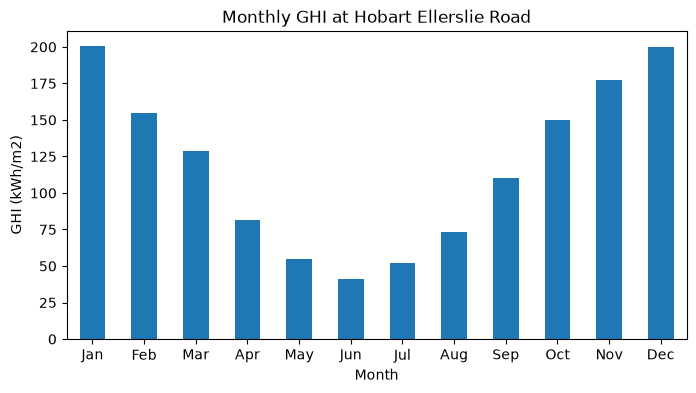

In [6]:
# Add up each month - grouped by month number because the months
# in a typical year file come from different years
monthly = sunlight.groupby(sunlight.index.month).sum() / 1000

# Month names for the x axis labels
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax = monthly["ghi"].plot(kind="bar", figsize=(8, 4))
ax.set_xticklabels(month_names, rotation=0)
plt.xlabel("Month")
plt.ylabel("GHI (kWh/m2)")
plt.title("Monthly GHI at Hobart Ellerslie Road")
plt.savefig("Images/monthly_ghi.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Check against Global Solar Atlas

The Global Solar Atlas has long-term average GHI as a raster. Read in the value in our study area, turn it into a yearly total and compare it with the total from the weather file.

In [7]:
# Global Solar Atlas GHI raster (long-term average, in kWh/m2 per day)
gsa_path = inpath / "LTAy_AvgDailyTotals" / "GHI.tif"

# Read the GSA value at the weather station location
with rasterio.open(gsa_path) as gsa:
    print("GSA CRS:", gsa.crs)
    location = [(station["longitude"], station["latitude"])]
    gsa_daily = list(gsa.sample(location))[0][0]

# GSA value is a daily average, so multiply by 365 for the yearly total
gsa_annual = gsa_daily * 365

print("GSA annual GHI:", round(gsa_annual), "kWh/m2")
print("EPW annual GHI:", round(annual_ghi), "kWh/m2")

GSA CRS: EPSG:4326
GSA annual GHI: 1353 kWh/m2
EPW annual GHI: 1424 kWh/m2


## 6. Summary of outputs

These are the files used in the next notebook.

| File | Folder | What it is |
|---|---|---|
| `BoundingBox_MGA2020.shp` | Inputs/BoundingBox | Study area in GDA2020 / MGA zone 55 |
| `Buildings_clipped_MGA2020.shp` | Outputs | Building footprints for the study area |
| `DSM_05mv2.tif` | Inputs/DSM | 0.5 m digital surface model |
| EPW weather file | Inputs/Ellerslie_Road_TMY | Hourly weather data for Hobart |